# Iteración 4: Clasificación Supervisada — Dataset General de Juegos Steam

**Integrantes**

- Juan Felipe Bejarano Salazar
- Gian Emanuel Morales González
- David Felipe Marin Rosas
- Luis Esteban León Rojas


## Objetivo

Aplicar técnicas de clasificación supervisada sobre el dataset general de juegos de Steam para predecir si un videojuego obtendrá críticas positivas (Very Positive / Overwhelmingly Positive) a partir de sus atributos de precio, tiempo de juego, plataformas, géneros y etiquetas.

### Variable Objetivo

A partir de review_score_cat construimos una variable binaria:

| Valor | Categoría original |
|---|---|
| **1 Éxito** | Very Positive, Overwhelmingly Positive |
| **0 No Éxito** | Mostly Positive, Mixed, Mostly Negative, Negative, Very Negative, Overwhelmingly Negative |

Los juegos sin reseñas o con muy pocas (No reviews, Too few reviews) se excluyen porque no aportan información confiable sobre la recepción del juego.

### Modelos comparados

1. **Árbol de Decisión:** Reglas interpretables basadas en ganancia de información.
2. **Naïve Bayes Gaussiano:** Clasificador probabilístico bajo supuesto de independencia de atributos.
3. **Red Neuronal MLP:** Perceptrón Multicapa con retropropagación y descenso de gradiente.


### 1. Importación de Librerías

In [3]:

# IMPORTACIÓN DE LIBRERÍAS

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocesamiento y partición
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler

# Modelos de Clasificación
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 2. Carga del Dataset

cargamos data_categorizado.csv ya que contiene todas las variables procesadas, las categorías derivadas y las columnas
One-Hot Encoded de géneros y etiquetas.


In [4]:
# CARGA DE data_categorizado.csv

paths = [
    'data_categorizado.csv',
    'Iteracion 4/code/data_categorizado.csv',
    '../data/data_categorizado.csv',
]

df_raw = None
for p in paths:
    if os.path.exists(p):
        df_raw = pd.read_csv(p)
        print(f"Dataset cargado desde: {p}")
        break

if df_raw is None:
    try:
        from google.colab import files
        print("Sube el archivo 'data_categorizado.csv':")
        uploaded = files.upload()
        df_raw = pd.read_csv(list(uploaded.keys())[0])
        print("Dataset cargado desde Colab upload.")
    except ImportError:
        raise FileNotFoundError(
            "No se encontró 'data_categorizado.csv'. "
            "Colócalo en el directorio de trabajo o cárgalo en Colab."
        )

print(f"\nDimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"Columnas OHE presentes:")
print(f"  genre_* : {sum(1 for c in df_raw.columns if c.startswith('genre_'))} columnas")
print(f"  tag_*   : {sum(1 for c in df_raw.columns if c.startswith('tag_'))} columnas")
df_raw.head(3)


Dataset cargado desde: data_categorizado.csv

Dimensiones: 114,174 filas × 131 columnas
Columnas OHE presentes:
  genre_* : 33 columnas
  tag_*   : 59 columnas


,appID,Name,Release date,Estimated owners,Peak CCU,Price,Discount,DLC count,About the game,Supported languages,...,tag_Simulation,tag_Singleplayer,tag_Story Rich,tag_Strategy,tag_Stylized,tag_Survival,tag_Third Person,tag_Top-Down,tag_VR,tag_Visual Novel
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,0,0,0,0,0,0,0,0,1
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,1,0,0,1,0,0,0,0,0
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,0,0,0,0,0,0,0


### 3. Definición del Target y Distribución de Clases



### 3.1 Definición del Target Binario

Se excluyen juegos sin información confiable de reseñas:
  - 'No reviews': 0 reseñas por lo tanto no es señal de calidad
  - 'Too few reviews': menos de 10 reseñas (umbral de la función steam_rating_category)

Target binario:
  1 Éxito: 'Very Positive'  y  'Overwhelmingly Positive'
  0 No Éxito: todas las demás categorías con reseñas suficientes

In [5]:
# FILTRADO Y DEFINICIÓN DEL TARGET

EXCLUIR = ['No reviews', 'Too few reviews']
SUCCESS  = ['Very Positive', 'Overwhelmingly Positive']

df = df_raw[~df_raw['review_score_cat'].isin(EXCLUIR)].copy()
df['target'] = df['review_score_cat'].apply(lambda x: 1 if x in SUCCESS else 0)

excluidos = len(df_raw) - len(df)
print(f"Juegos excluidos (sin reseñas suficientes) : {excluidos:,}")
print(f"Dataset para clasificación                 : {len(df):,} juegos")
print()
print("Categorías que componen cada clase:")
print(df.groupby(['target', 'review_score_cat']).size().to_string())


Juegos excluidos (sin reseñas suficientes) : 57,520
Dataset para clasificación                 : 56,654 juegos

Categorías que componen cada clase:
target  review_score_cat       
0       Mixed                      13770
        Mostly Negative             2094
        Mostly Positive            19040
        Negative                     293
        Overwhelmingly Negative       11
        Very Negative                 56
1       Overwhelmingly Positive     1266
        Very Positive              20124


### 3.2 Desbalance de Clases Por qué el Accuracy Engaña

Con un 62% de clase 0, un clasificador que SIEMPRE prediga 0 alcanzaría un Accuracy del 62% sin aprender ningún patrón. Por eso se usarán F1-Score y ROC-AUC como métricas principales de evaluación.

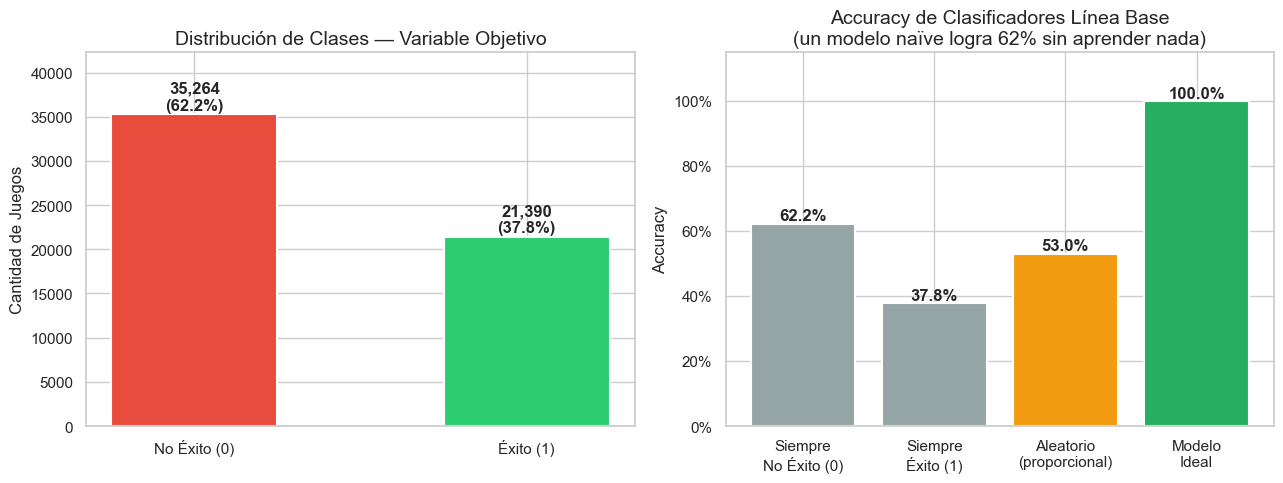

Accuracy del clasificador naïve (siempre clase 0): 62.2%
Métricas principales: F1-Score y ROC-AUC.


In [6]:
# DISTRIBUCIÓN DEL TARGET Y DESBALANCE DE CLASES

cnt = df['target'].value_counts()
pct = df['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: distribución de clases
bars = axes[0].bar(
    ['No Éxito (0)', 'Éxito (1)'],
    cnt.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val, p in zip(bars, cnt.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}\n({p:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de Clases — Variable Objetivo')
axes[0].set_ylabel('Cantidad de Juegos')
axes[0].set_ylim(0, cnt.max() * 1.2)

# Panel derecho: Accuracy de clasificadores ingenuos
acc_0 = pct[0] / 100
acc_1 = pct[1] / 100
estrategias = ['Siempre\nNo Éxito (0)', 'Siempre\nÉxito (1)',
               'Aleatorio\n(proporcional)', 'Modelo\nIdeal']
acc_vals = [acc_0, acc_1, acc_0**2 + acc_1**2, 1.0]
axes[1].bar(estrategias, acc_vals,
            color=['#95a5a6','#95a5a6','#f39c12','#27ae60'],
            edgecolor='white', linewidth=1.5)
for i, v in enumerate(acc_vals):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].set_title(f'Accuracy de Clasificadores Línea Base\n'
                  f'(un modelo naïve logra {acc_0:.0%} sin aprender nada)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"Accuracy del clasificador naïve (siempre clase 0): {acc_0:.1%}")
print("Métricas principales: F1-Score y ROC-AUC.")


### 4. Verificación del Preprocesamiento



#### 4.1 Verificación de Variables OHE — Géneros y Tags

Las columnas genre_* y tag_* fueron creadas en la iteracion 2:

**Géneros (genre_*):**
- OHE completo sobre los 33 géneros únicos del dataset original.
- No hay filtro de frecuencia y todos los géneros están representados.

**Tags (tag_*):**
- OHE aplicado SOLO a los tags con una frecuencia de 5000 o mas apariciones 
- En el dataset completo de 452 tags únicos, quedaron 59 frecuentes
- Este filtro evita columnas demasiado dispersas que perjudicarían los algoritmos de asociación y clasificación.

In [7]:
# VERIFICACIÓN DE COLUMNAS OHE genre_* y tag_*

genre_cols = [c for c in df.columns if c.startswith('genre_')]
tag_cols   = [c for c in df.columns if c.startswith('tag_')]

print("Verificación de columnas OHE (creadas en iteracion 2):")
print(f"  genre_* : {len(genre_cols)} columnas  → OHE completo de los 33 géneros")
print(f"  tag_*   : {len(tag_cols)} columnas   → Tags con frecuencia ≥ 5 000")
print()

# Verificar que son binarias (0/1)
genre_non_binary = sum(
    1 for c in genre_cols if not set(df[c].unique()).issubset({0, 1})
)
tag_non_binary = sum(
    1 for c in tag_cols if not set(df[c].unique()).issubset({0, 1})
)
print(f"  Columnas genre_* no-binarias : {genre_non_binary}  (esperado: 0)")
print(f"  Columnas tag_*   no-binarias : {tag_non_binary}  (esperado: 0)")

# Verificar que no hay nulos en OHE
genre_nulls = df[genre_cols].isnull().sum().sum()
tag_nulls   = df[tag_cols].isnull().sum().sum()
print(f"  Nulos en genre_* : {genre_nulls}  (esperado: 0)")
print(f"  Nulos en tag_*   : {tag_nulls}  (esperado: 0)")

print()
print("Tags incluidos (frecuencia ≥ 5 000 en el dataset completo):")
print([c.replace('tag_', '') for c in tag_cols])


Verificación de columnas OHE (creadas en iteracion 2):
  genre_* : 33 columnas  → OHE completo de los 33 géneros
  tag_*   : 59 columnas   → Tags con frecuencia ≥ 5 000

  Columnas genre_* no-binarias : 0  (esperado: 0)
  Columnas tag_*   no-binarias : 0  (esperado: 0)
  Nulos en genre_* : 0  (esperado: 0)
  Nulos en tag_*   : 0  (esperado: 0)

Tags incluidos (frecuencia ≥ 5 000 en el dataset completo):
['2D', '2D Platformer', '3D', 'Action', 'Action-Adventure', 'Adventure', 'Anime', 'Arcade', 'Atmospheric', 'Cartoony', 'Casual', 'Choices Matter', 'Co-op', 'Colorful', 'Combat', 'Comedy', 'Controller', 'Cute', 'Dark', 'Difficult', 'Early Access', 'Exploration', 'FPS', 'Family Friendly', 'Fantasy', 'Female Protagonist', 'First-Person', 'Funny', 'Horror', 'Indie', 'Linear', 'Minimalist', 'Multiplayer', 'Multiple Endings', 'Mystery', 'Open World', 'Physics', 'Pixel Graphics', 'Platformer', 'Point & Click', 'Psychological Horror', 'Puzzle', 'PvE', 'RPG', 'Realistic', 'Relaxing', 'Retro', 'S

### 4.2 Verificación de Variables Numéricas
El preprocesamiento numérico fue hecho en la iteracion 0 en la cual:
  - Verificamos la integridad de rangos (no negativos, Discount en [0,100], etc.)
  - Confirmamos que ninguna columna numérica tenía valores faltantes

In [8]:
# VERIFICACIÓN DE VARIABLES NUMÉRICAS


NUMERIC_FEATURES = [
    'Price', 'Discount', 'DLC count', 'Metacritic score', 'Achievements',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks',
    'Peak CCU', 'Release_year', 'Release_month'
]
BINARY_FEATURES = ['Windows', 'Mac', 'Linux']

print("Verificación de integridad — Variables numéricas:")
print(f"{'Variable':<35} {'Nulos':>6}  {'Min':>10}  {'Max':>12}")
print("-" * 68)
todo_ok = True
for col in NUMERIC_FEATURES:
    nulos = df[col].isnull().sum()
    vmin  = df[col].min()
    vmax  = df[col].max()
    
    print(f"  {col:<33} {nulos:>6}  {vmin:>10.2f}  {vmax:>12.2f}")
    if nulos > 0:
        todo_ok = False

print()
if todo_ok:
    print("Sin valores nulos en variables numéricas, consistente con")
    print("el preprocesamiento de la iteracion 0")
else:
    print("Se detectaron nulos — revisar pipeline de preprocesamiento.")

# Variables booleanas → convertir a int para scikit-learn
for col in BINARY_FEATURES:
    df[col] = df[col].astype(int)
print()
print(f"Variables binarias {BINARY_FEATURES} convertidas a int (0/1).")


Verificación de integridad — Variables numéricas:
Variable                             Nulos         Min           Max
--------------------------------------------------------------------
  Price                                  0        0.00        299.99
  Discount                               0        0.00        100.00
  DLC count                              0        0.00       3703.00
  Metacritic score                       0        0.00         97.00
  Achievements                           0        0.00       9821.00
  Average playtime forever               0        0.00    3429544.00
  Average playtime two weeks             0        0.00      20088.00
  Median playtime forever                0        0.00    3429544.00
  Median playtime two weeks              0        0.00      20088.00
  Peak CCU                               0        0.00    1013936.00
  Release_year                           0     1997.00       2025.00
  Release_month                          0        1.0

### 4.3 Selección de Features
Se excluyen variables que causarían data leakage:
- Positive, Negative, total_reviews, review_rate: definen matemáticamente review_score_cat (target). El modelo haría trampa.
- review_score_cat es la fuente del target binario.
- sales_cat, ccu_cat, metacritic_cat: son otras variables objetivo creadas en la iteracion 2 que no estan disponibles en la predicción.

In [9]:
# SELECCIÓN DE FEATURES

all_features = NUMERIC_FEATURES + BINARY_FEATURES + genre_cols + tag_cols

X = df[all_features].copy()
y = df['target'].copy()

print("Composición del conjunto de features:")
print(f"  Numéricas continuas : {len(NUMERIC_FEATURES)}")
print(f"  Binarias (OS)       : {len(BINARY_FEATURES)}")
print(f"  OHE géneros         : {len(genre_cols)}")
print(f"  OHE tags            : {len(tag_cols)}")
print(f"  ─────────────────────")
print(f"  Total features      : {X.shape[1]}")
print(f"  Total muestras      : {X.shape[0]:,}")
print()
print(f"Nulos restantes en X : {X.isnull().sum().sum()}  (esperado: 0)")


Composición del conjunto de features:
  Numéricas continuas : 12
  Binarias (OS)       : 3
  OHE géneros         : 33
  OHE tags            : 59
  ─────────────────────
  Total features      : 107
  Total muestras      : 56,654

Nulos restantes en X : 0  (esperado: 0)


### 5. Partición del Dataset

implementamos dos estrategias de partición:

- **Holdout (80/20):** es rápido y sirve para el entrenamiento y evaluación final.
- **K-Fold CV (10 pliegues):** estimación más robusta del error de generalización.

En ambos casos se hace estratificación para mantener la proporción de las clases.


### Holdout
stratify = y garantiza que la proporción 62% / 38% se replique en ambos subconjuntos, lo que es fundamental dado el desbalance de clases. El StandardScaler se ajusta solo sobre el conjunto de entrenamiento y luego lo aplicamos al de prueba, esto nos evita que los estadísticos de prueba contaminen la normalización (que haya data leakage en el preprocesamiento).
Solo escalamos las variables numéricas continuas ya que las binarias OHE ya están en escala 0/1 y no requieren transformación.

In [10]:
# HOLDOUT 80% train 20% test


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

print("Partición Holdout (80/20) — estratificada:")
print(f"  Entrenamiento : {X_train.shape[0]:,} muestras  "
      f"| Éxito={y_train.sum():,}  No Éxito={(y_train==0).sum():,}")
print(f"  Prueba        : {X_test.shape[0]:,} muestras  "
      f"| Éxito={y_test.sum():,}  No Éxito={(y_test==0).sum():,}")
print()
print(f"  Proporción Éxito — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print(" Estratificación correcta: proporciones idénticas en ambos conjuntos.")
print()

# K-Fold CV
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("K-Fold Cross-Validation configurado:")
print(f"  k=10 pliegues, Stratified, random_state=42")
print(f"  Se aplicará sobre los {X_train.shape[0]:,} datos de entrenamiento.")


Partición Holdout (80/20) — estratificada:
  Entrenamiento : 45,323 muestras  | Éxito=17,112  No Éxito=28,211
  Prueba        : 11,331 muestras  | Éxito=4,278  No Éxito=7,053

  Proporción Éxito — Train: 0.378 | Test: 0.378
 Estratificación correcta: proporciones idénticas en ambos conjuntos.

K-Fold Cross-Validation configurado:
  k=10 pliegues, Stratified, random_state=42
  Se aplicará sobre los 45,323 datos de entrenamiento.


### 6. Aplicación de Modelos de Clasificación


### 6.1 Árbol de Decisión

En cada nodo el árbol elige el atributo que maximiza la reducción de impureza
medida por el **Índice de Gini**:

$$\text{Gini}(D) = 1 - \sum_{k} p_k^2$$

$$\text{Ganancia}(D, A) = \text{Gini}(D) - \sum_{v} \frac{|D_v|}{|D|} \cdot \text{Gini}(D_v)$$

Como resultado obtenemos un conjunto de reglas lógicas interpretables.
`max_depth` y `min_samples_leaf` controlan la complejidad para evitar sobreajuste.


In [11]:
# ==============================================================================
# ÁRBOL DE DECISIÓN
# ==============================================================================

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt       = dt_model.predict(X_test)
y_prob_dt       = dt_model.predict_proba(X_test)[:, 1]
y_pred_dt_train = dt_model.predict(X_train)

print("Árbol de Decisión entrenado.")
print(f"   Profundidad real  : {dt_model.get_depth()}")
print(f"   Número de hojas   : {dt_model.get_n_leaves()}")
print(f"   Accuracy (train)  : {accuracy_score(y_train, y_pred_dt_train):.4f}")
print(f"   Accuracy (test)   : {accuracy_score(y_test, y_pred_dt):.4f}")


Árbol de Decisión entrenado.
   Profundidad real  : 10
   Número de hojas   : 383
   Accuracy (train)  : 0.7154
   Accuracy (test)   : 0.6804


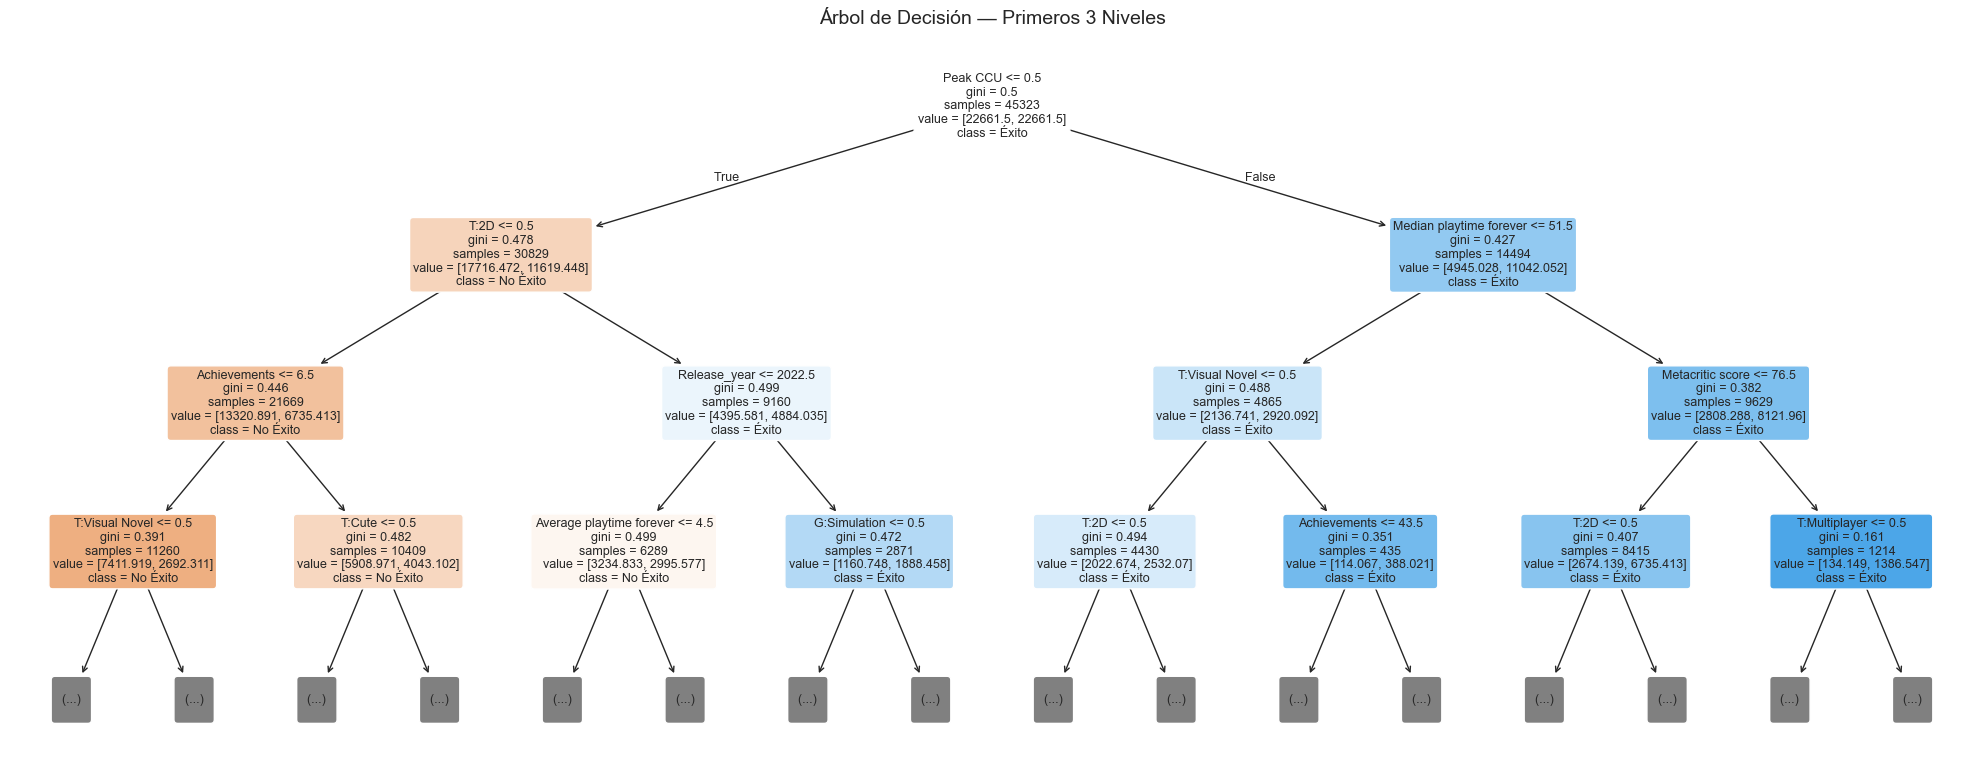

Top 10 features más importantes (Gini):
Peak CCU                   0.3383
tag_2D                     0.1012
Release_year               0.0778
Achievements               0.0545
Median playtime forever    0.0515
Discount                   0.0405
tag_Visual Novel           0.0358
Price                      0.0329
tag_Cute                   0.0311
Metacritic score           0.0297


In [12]:
# Visualización del árbol (3 niveles)
feat_short = (
    NUMERIC_FEATURES + BINARY_FEATURES +
    [c.replace('genre_','G:') for c in genre_cols] +
    [c.replace('tag_','T:')   for c in tag_cols]
)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feat_short,
    class_names=['No Éxito', 'Éxito'],
    filled=True, rounded=True, max_depth=3,
    fontsize=9, ax=ax, impurity=True
)
ax.set_title('Árbol de Decisión — Primeros 3 Niveles', fontsize=14)
plt.tight_layout()
plt.show()

print("Top 10 features más importantes (Gini):")
feat_imp = pd.Series(
    dt_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(10)
print(feat_imp.round(4).to_string())


### 6.2 Naïve Bayes Gaussiano

Aplicamos el **Teorema de Bayes** asumiendo independencia condicional entre atributos:

$$P(C \mid x_1,\ldots,x_n) \propto P(C)\prod_{i=1}^{n} P(x_i \mid C)$$

La versión **Gaussiana** modela $P(x_i \mid C)$ como una distribución normal.
El supuesto de independencia puede violarse cuando existen correlaciones entre features lo que puede reducir su precisión.


In [13]:
# ==============================================================================
# NAÏVE BAYES GAUSSIANO
# ==============================================================================

nb_model = GaussianNB(var_smoothing=1e-9)
nb_model.fit(X_train_scaled, y_train)

y_pred_nb       = nb_model.predict(X_test_scaled)
y_prob_nb       = nb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_nb_train = nb_model.predict(X_train_scaled)

print("Naïve Bayes Gaussiano entrenado.")
print(f"   Accuracy (train) : {accuracy_score(y_train, y_pred_nb_train):.4f}")
print(f"   Accuracy (test)  : {accuracy_score(y_test, y_pred_nb):.4f}")
print()
print("Medias aprendidas por clase (primeras 5 variables numéricas):")
print(pd.DataFrame(
    nb_model.theta_[:, :5],
    columns=NUMERIC_FEATURES[:5],
    index=['No Éxito (0)', 'Éxito (1)']
).round(3).to_string())


Naïve Bayes Gaussiano entrenado.
   Accuracy (train) : 0.4098
   Accuracy (test)  : 0.4087

Medias aprendidas por clase (primeras 5 variables numéricas):
              Price  Discount  DLC count  Metacritic score  Achievements
No Éxito (0) -0.017    -0.057     -0.012            -0.116        -0.005
Éxito (1)     0.028     0.094      0.020             0.190         0.008


### 6.3 Red Neuronal Perceptrón Multicapa (MLP)

Red neuronal feedforward con capas ocultas. Usa **retropropagación** para calcular gradientes y el optimizador **Adam** para actualizar pesos:

$$w \leftarrow w - \eta \cdot \nabla_w \mathcal{L}$$

Arquitectura elegida: **128 → 64 → 32** neuronas. La reducción progresiva forma
un "embudo" que comprime la representación hacia patrones más abstractos.
`early_stopping` detiene el entrenamiento si el score de validación no mejora,
previniendo sobreajuste.


In [14]:
# ==============================================================================
# RED NEURONAL MLP
# ==============================================================================

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)

print("Entrenando Red Neuronal MLP…")
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp       = mlp_model.predict(X_test_scaled)
y_prob_mlp       = mlp_model.predict_proba(X_test_scaled)[:, 1]
y_pred_mlp_train = mlp_model.predict(X_train_scaled)

print("Red Neuronal MLP entrenada.")
print(f"   Épocas ejecutadas : {mlp_model.n_iter_}")
print(f"   Pérdida final     : {mlp_model.loss_:.4f}")
print(f"   Accuracy (train)  : {accuracy_score(y_train, y_pred_mlp_train):.4f}")
print(f"   Accuracy (test)   : {accuracy_score(y_test, y_pred_mlp):.4f}")


Entrenando Red Neuronal MLP…
Red Neuronal MLP entrenada.
   Épocas ejecutadas : 19
   Pérdida final     : 0.4301
   Accuracy (train)  : 0.7191
   Accuracy (test)   : 0.6969


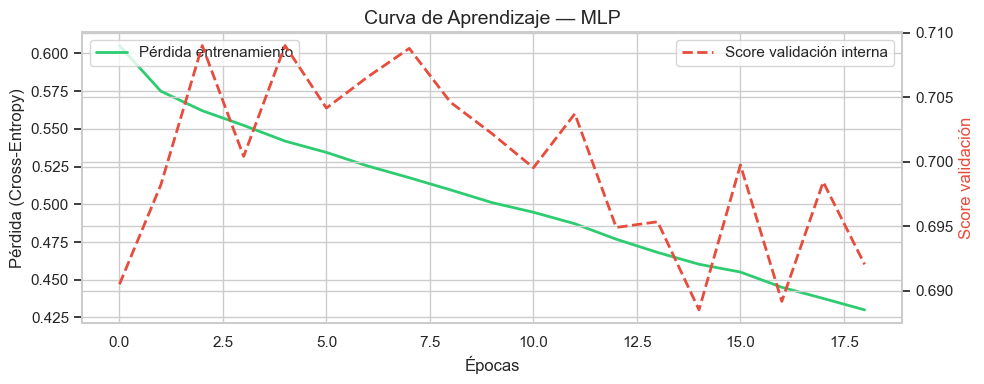

In [15]:
# Curva de aprendizaje del MLP
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_model.loss_curve_, color='#2ecc71', linewidth=2,
        label='Pérdida entrenamiento')
if hasattr(mlp_model, 'validation_scores_') and mlp_model.validation_scores_:
    ax2 = ax.twinx()
    ax2.plot(mlp_model.validation_scores_, color='#e74c3c',
             linewidth=2, linestyle='--', label='Score validación interna')
    ax2.set_ylabel('Score validación', color='#e74c3c')
    ax2.legend(loc='upper right')
ax.set_xlabel('Épocas')
ax.set_ylabel('Pérdida (Cross-Entropy)')
ax.set_title('Curva de Aprendizaje — MLP')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### 7. Evaluación del Modelo y Métricas


### 7.1 Matrices de Confusión

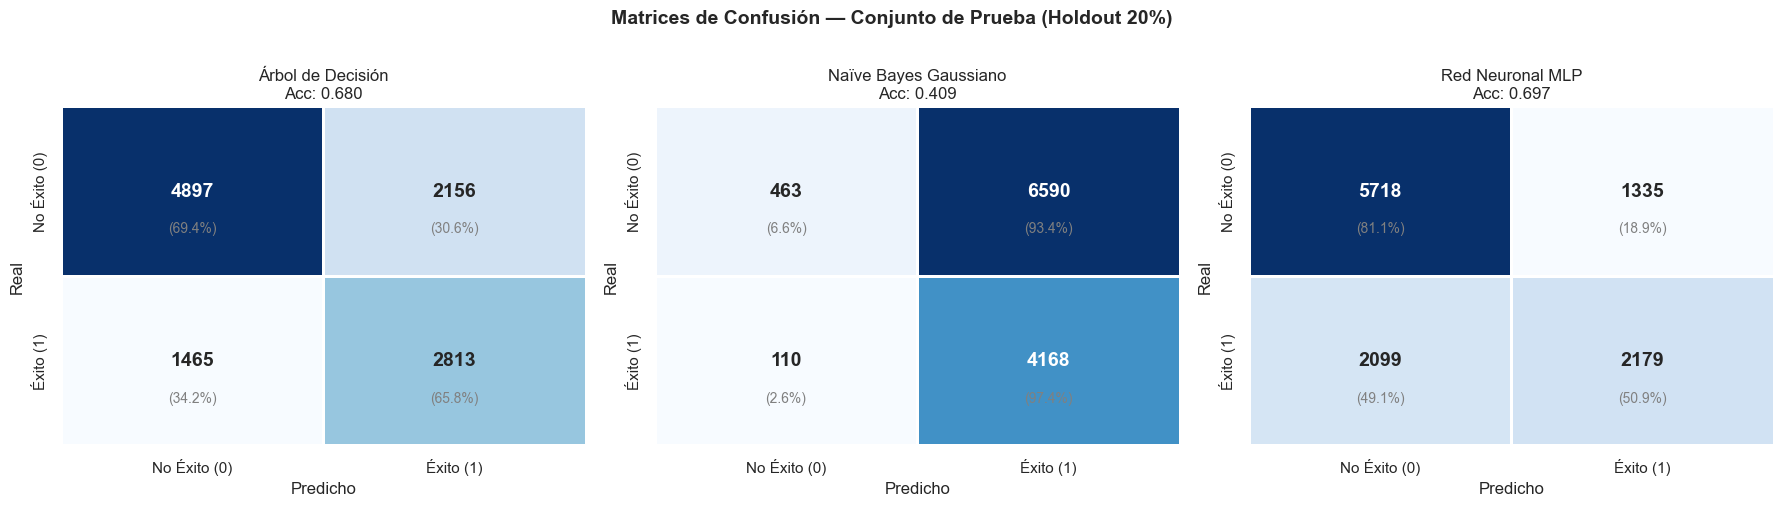

In [16]:
MODELS_INFO = [
    ('Árbol de Decisión',     y_pred_dt,  '#3498db'),
    ('Naïve Bayes Gaussiano', y_pred_nb,  '#9b59b6'),
    ('Red Neuronal MLP',      y_pred_mlp, '#e67e22'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, _) in zip(axes, MODELS_INFO):
    cm      = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Éxito (0)', 'Éxito (1)'],
        yticklabels=['No Éxito (0)', 'Éxito (1)'],
        ax=ax, linewidths=2, linecolor='white',
        cbar=False, annot_kws={'size': 14, 'weight': 'bold'}
    )
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]:.1%})',
                    ha='center', va='center', fontsize=10, color='gray')
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f}',
                 fontsize=12)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba (Holdout 20%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.2 Tabla de Métricas Comparativa

In [17]:
# ==============================================================================
# MÉTRICAS DE DESEMPEÑO
# ==============================================================================

filas = []
for nombre, y_pred, y_prob in [
    ('Árbol de Decisión',     y_pred_dt,  y_prob_dt),
    ('Naïve Bayes Gaussiano', y_pred_nb,  y_prob_nb),
    ('Red Neuronal MLP',      y_pred_mlp, y_prob_mlp),
]:
    filas.append({
        'Modelo'    : nombre,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(filas).set_index('Modelo')

print("=" * 70)
print("TABLA COMPARATIVA — CONJUNTO DE PRUEBA (Holdout 20%)")
print("=" * 70)
print(results_df.round(4).to_string())
print()
print(f"Mejor F1-Score : {results_df['F1-Score'].idxmax()}  "
      f"({results_df['F1-Score'].max():.4f})")
print(f"Mejor ROC-AUC  : {results_df['ROC-AUC'].idxmax()}  "
      f"({results_df['ROC-AUC'].max():.4f})")


TABLA COMPARATIVA — CONJUNTO DE PRUEBA (Holdout 20%)
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                               
Árbol de Decisión        0.6804     0.5661  0.6576    0.6084   0.7381
Naïve Bayes Gaussiano    0.4087     0.3874  0.9743    0.5544   0.6759
Red Neuronal MLP         0.6969     0.6201  0.5094    0.5593   0.7425

Mejor F1-Score : Árbol de Decisión  (0.6084)
Mejor ROC-AUC  : Red Neuronal MLP  (0.7425)


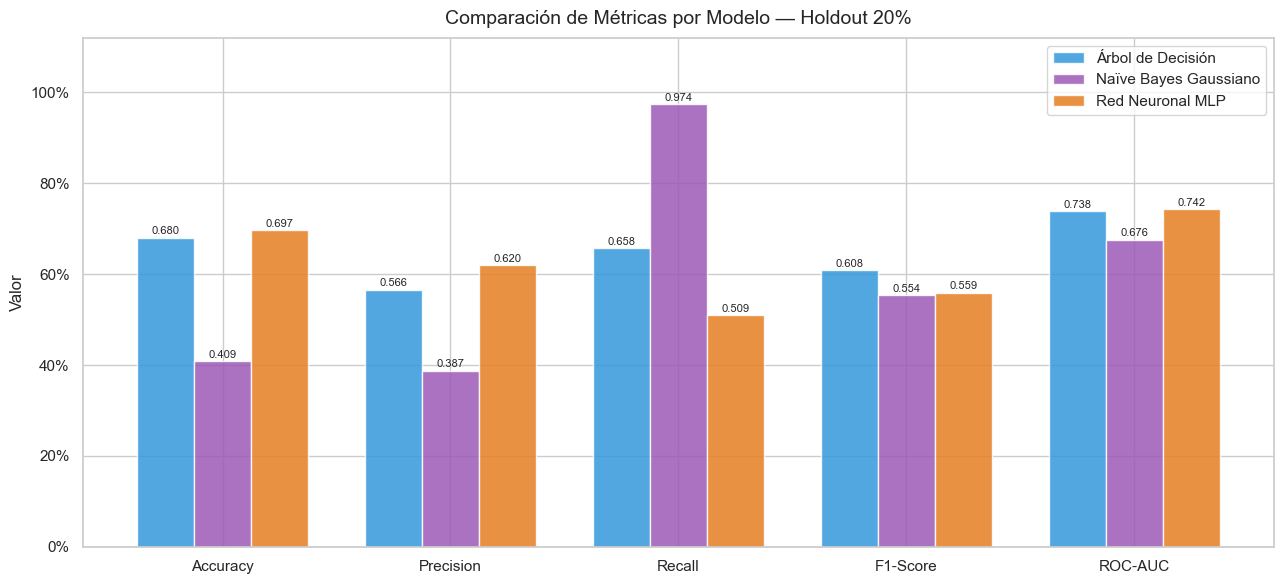

In [18]:
# Gráfico comparativo de métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metricas))
w = 0.25
colores = ['#3498db', '#9b59b6', '#e67e22']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (modelo, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + (i-1)*w, row[metricas].values, w,
                  label=modelo, color=colores[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas por Modelo — Holdout 20%', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


In [19]:
# Reportes de clasificación detallados
for nombre, y_pred, _ in [
    ('Árbol de Decisión',     y_pred_dt,  None),
    ('Naïve Bayes Gaussiano', y_pred_nb,  None),
    ('Red Neuronal MLP',      y_pred_mlp, None),
]:
    print(f"\n{'-'*60}")
    print(f"  REPORTE — {nombre}")
    print('-'*60)
    print(classification_report(
        y_test, y_pred,
        target_names=['No Éxito (0)', 'Éxito (1)'],
        digits=4
    ))



------------------------------------------------------------
  REPORTE — Árbol de Decisión
------------------------------------------------------------
              precision    recall  f1-score   support

No Éxito (0)     0.7697    0.6943    0.7301      7053
   Éxito (1)     0.5661    0.6576    0.6084      4278

    accuracy                         0.6804     11331
   macro avg     0.6679    0.6759    0.6692     11331
weighted avg     0.6929    0.6804    0.6841     11331


------------------------------------------------------------
  REPORTE — Naïve Bayes Gaussiano
------------------------------------------------------------
              precision    recall  f1-score   support

No Éxito (0)     0.8080    0.0656    0.1214      7053
   Éxito (1)     0.3874    0.9743    0.5544      4278

    accuracy                         0.4087     11331
   macro avg     0.5977    0.5200    0.3379     11331
weighted avg     0.6492    0.4087    0.2849     11331


-----------------------------------

### 7.3 Curvas ROC y AUC

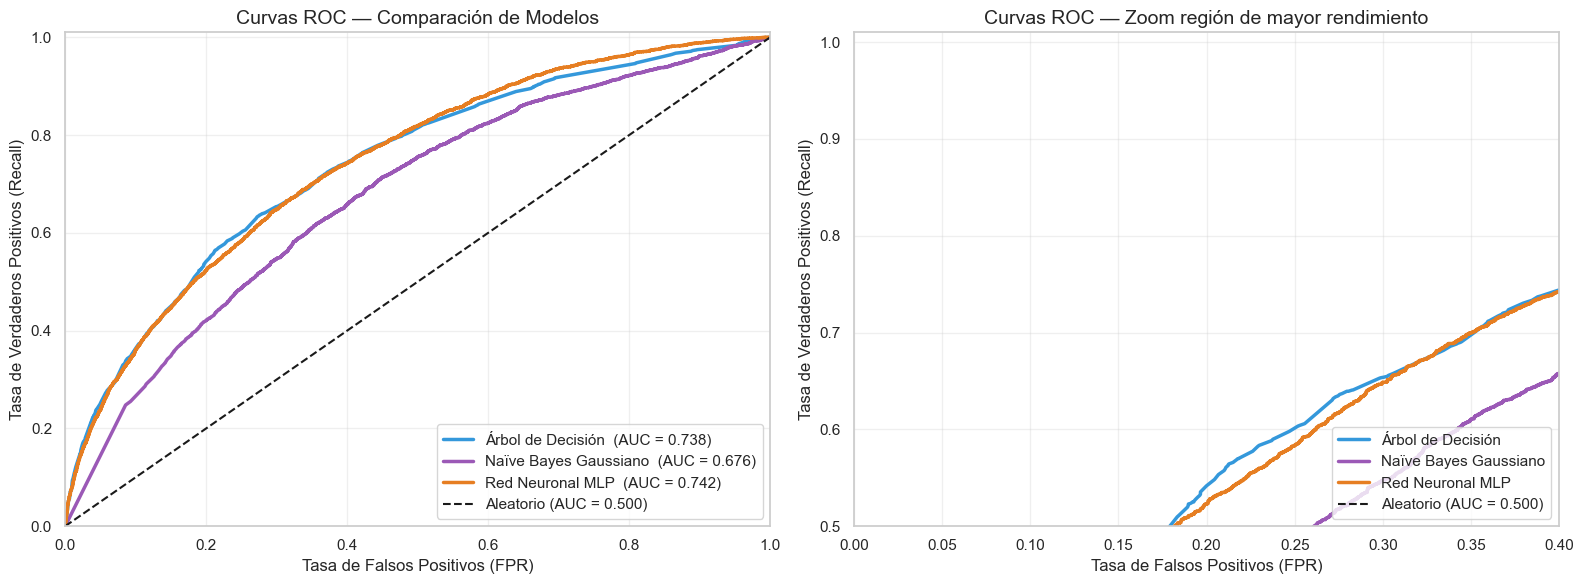

In [20]:
# CURVAS ROC

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

MODELS_ROC = [
    ('Árbol de Decisión',     y_prob_dt,  '#3498db'),
    ('Naïve Bayes Gaussiano', y_prob_nb,  '#9b59b6'),
    ('Red Neuronal MLP',      y_prob_mlp, '#e67e22'),
]

for name, y_prob, color in MODELS_ROC:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_val     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name}  (AUC = {roc_val:.3f})')
    axes[1].plot(fpr, tpr, color=color, linewidth=2.5, label=name)

for ax in axes:
    ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Aleatorio (AUC = 0.500)')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

axes[0].set_title('Curvas ROC — Comparación de Modelos')
axes[0].set_xlim([0, 1]);  axes[0].set_ylim([0, 1.01])

axes[1].set_title('Curvas ROC — Zoom región de mayor rendimiento')
axes[1].set_xlim([0, 0.40]); axes[1].set_ylim([0.50, 1.01])

plt.tight_layout()
plt.show()


### 7.4 Validación Cruzada — 10-Fold

In [21]:
# K-FOLD CROSS-VALIDATION (10 pliegues, estratificado)

print("Ejecutando 10-Fold Cross-Validation")
print()

CV_MODELS = [
    ('Árbol de Decisión', DecisionTreeClassifier(
        criterion='gini', max_depth=10, min_samples_split=50,
        min_samples_leaf=20, class_weight='balanced', random_state=42)),
    ('Naïve Bayes',       GaussianNB(var_smoothing=1e-9)),
    ('Red Neuronal MLP',  MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
        alpha=0.001, learning_rate='adaptive', max_iter=200,
        early_stopping=True, random_state=42, verbose=False)),
]

cv_results = {}
for name, model in CV_MODELS:
    X_cv = X_train_scaled if name != 'Árbol de Decisión' else X_train
    scores = cross_val_score(model, X_cv, y_train,
                             cv=kfold, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name}:")
    print(f"    F1 por pliegue : {scores.round(3)}")
    print(f"    Media ± Std    : {scores.mean():.4f} ± {scores.std():.4f}")
    print()


Ejecutando 10-Fold Cross-Validation



Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
Traceback (most recent call last):
Traceback (most recent call last):
  File "<frozen runpy>", line 112, in _get_module_details
  File "/home/adminblend/.pyenv/versions/3.12.7/lib/python3.12/site-packages/joblib/__init__.py", line 120, in <module>
  File "/home/adminblend/.pyenv/versions/3.12.7/lib/python3.12/site-packages/joblib/__init__.py", line 120, in <module>
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "/home/adminblend/.pyenv/versions/3.12.7/lib/python3.12/

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
cv_data  = [cv_results[n] for n in cv_results]
cv_names = list(cv_results.keys())
bp = axes[0].boxplot(cv_data, labels=cv_names, patch_artist=True,
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['#3498db','#9b59b6','#e67e22']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Distribución F1-Score — 10-Fold CV')
axes[0].set_ylabel('F1-Score')
axes[0].tick_params(axis='x', rotation=10)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Curvas por pliegue
for name, color in zip(cv_names, ['#3498db','#9b59b6','#e67e22']):
    s = cv_results[name]
    axes[1].plot(range(1,11), s, 'o-', color=color,
                 label=f'{name}  (μ={s.mean():.3f})', linewidth=2, markersize=6)
axes[1].set_xlabel('Pliegue')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score por Pliegue — 10-Fold CV')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(1,11))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()


### 8. Conclusiones 

### 8.1 Diagnóstico de Overfitting

DIAGNÓSTICO DE SOBREAJUSTE
                   Acc. Train  Acc. Test  Δ (Train-Test)
Modelo                                                  
Árbol de Decisión      0.7154     0.6804          0.0350
Naïve Bayes            0.4098     0.4087          0.0011
Red Neuronal MLP       0.7191     0.6969          0.0222

  Árbol de Decisión        : Buen equilibrio      (Δ = 0.035)
  Naïve Bayes              : Buen equilibrio      (Δ = 0.001)
  Red Neuronal MLP         : Buen equilibrio      (Δ = 0.022)


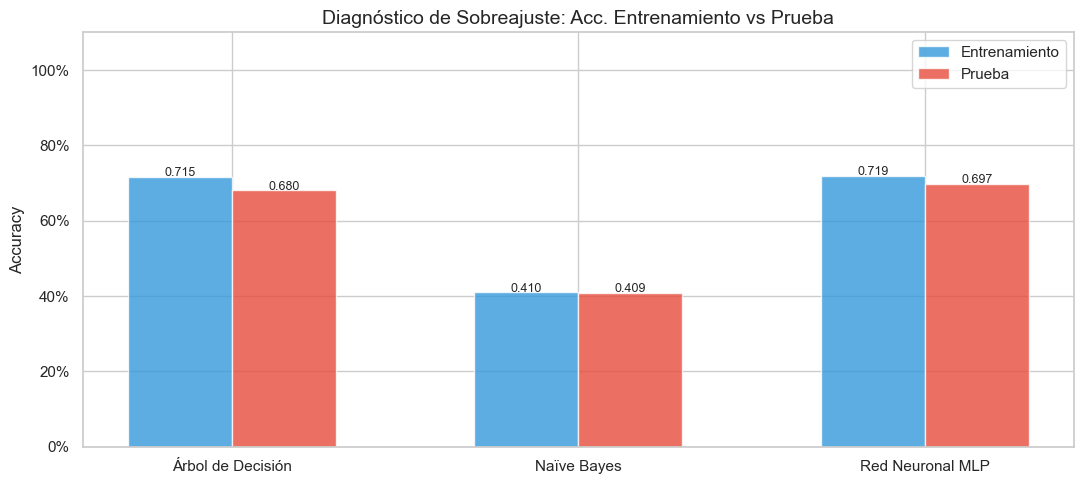

In [23]:
# COMPARACIÓN ENTRENAMIENTO vs PRUEBA

diag = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Naïve Bayes', 'Red Neuronal MLP'],
    'Acc. Train': [
        accuracy_score(y_train, y_pred_dt_train),
        accuracy_score(y_train, y_pred_nb_train),
        accuracy_score(y_train, y_pred_mlp_train),
    ],
    'Acc. Test': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_mlp),
    ]
}).set_index('Modelo')
diag['Δ (Train-Test)'] = diag['Acc. Train'] - diag['Acc. Test']

print("DIAGNÓSTICO DE SOBREAJUSTE")
print(diag.round(4).to_string())
print()
for idx, row in diag.iterrows():
    d = row['Δ (Train-Test)']
    if d > 0.05:
        diag_txt = f"Sobreajuste moderado (Δ = {d:.3f})"
    elif d < -0.02:
        diag_txt = f"Posible subajuste   (Δ = {d:.3f})"
    else:
        diag_txt = f"Buen equilibrio      (Δ = {d:.3f})"
    print(f"  {idx:25s}: {diag_txt}")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(3); w = 0.3
b1 = ax.bar(x-w/2, diag['Acc. Train'], w, label='Entrenamiento',
            color='#3498db', alpha=0.8, edgecolor='white')
b2 = ax.bar(x+w/2, diag['Acc. Test'],  w, label='Prueba',
            color='#e74c3c', alpha=0.8, edgecolor='white')
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['Árbol de Decisión', 'Naïve Bayes', 'Red Neuronal MLP'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Diagnóstico de Sobreajuste: Acc. Entrenamiento vs Prueba')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


### 8.2 Análisis de Matrices de Costo

In [25]:
# ANÁLISIS DE MATRICES DE COSTO

print("ANÁLISIS DE ERRORES — Contexto Steam / Publicación de Videojuegos")
for nombre, y_pred in [
    ('Árbol de Decisión',     y_pred_dt),
    ('Naïve Bayes Gaussiano', y_pred_nb),
    ('Red Neuronal MLP',      y_pred_mlp),
]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    print(f"\n  {nombre}")
    print(f"    TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
    print(f"    Precision={prec:.3f}  Recall={rec:.3f}")
    print(f"    FP → juegos mal etiquetados como Éxito : {fp:,}")
    print(f"    FN → oportunidades perdidas            : {fn:,}")


ANÁLISIS DE ERRORES — Contexto Steam / Publicación de Videojuegos

  Árbol de Decisión
    TP=2,813  FP=2,156  FN=1,465  TN=4,897
    Precision=0.566  Recall=0.658
    FP → juegos mal etiquetados como Éxito : 2,156
    FN → oportunidades perdidas            : 1,465

  Naïve Bayes Gaussiano
    TP=4,168  FP=6,590  FN=110  TN=463
    Precision=0.387  Recall=0.974
    FP → juegos mal etiquetados como Éxito : 6,590
    FN → oportunidades perdidas            : 110

  Red Neuronal MLP
    TP=2,179  FP=1,335  FN=2,099  TN=5,718
    Precision=0.620  Recall=0.509
    FP → juegos mal etiquetados como Éxito : 1,335
    FN → oportunidades perdidas            : 2,099


### 8.3 Resumen

In [27]:
print("RESUMEN FINAL — CLASIFICACIÓN DE JUEGOS STEAM")
print()
print(f"  Dataset     : {df.shape[0]:,} juegos con reseñas suficientes")
print(f"  Features    : {X.shape[1]} (numéricas + OHE géneros/tags)")
print(f"  Target      : 1=Éxito ({y.mean():.1%})  |  0=No Éxito ({(1-y.mean()):.1%})")
print()
print(" HOLDOUT 20% ")
print(results_df.round(4).to_string())
print()
print(" 10-FOLD CV  (F1 media ± std)")
for name in cv_results:
    s = cv_results[name]
    print(f"  {name:25s}: {s.mean():.4f} ± {s.std():.4f}")
print()
print(f"Mejor F1  (Holdout) : {results_df['F1-Score'].idxmax()}")
print(f"Mejor AUC (Holdout) : {results_df['ROC-AUC'].idxmax()}")


RESUMEN FINAL — CLASIFICACIÓN DE JUEGOS STEAM

  Dataset     : 56,654 juegos con reseñas suficientes
  Features    : 107 (numéricas + OHE géneros/tags)
  Target      : 1=Éxito (37.8%)  |  0=No Éxito (62.2%)

 HOLDOUT 20% 
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                               
Árbol de Decisión        0.6804     0.5661  0.6576    0.6084   0.7381
Naïve Bayes Gaussiano    0.4087     0.3874  0.9743    0.5544   0.6759
Red Neuronal MLP         0.6969     0.6201  0.5094    0.5593   0.7425

 10-FOLD CV  (F1 media ± std)

Mejor F1  (Holdout) : Árbol de Decisión
Mejor AUC (Holdout) : Red Neuronal MLP
